## Lab 4: Inference and Qualitative Testing 

**⏱️ Estimated completion time: 10 minutes**

### Lab overview

Brief: This lab demonstrates how to test and validate your deployed fine-tuned Nova-Lite model using real document images and questions. You'll learn to perform inference calls, evaluate model responses, and compare outputs against expected answers to assess the effectiveness of your fine-tuning process.

Expected outputs: Visual comparisons of model responses vs expected answers, quantitative assessment of model performance on document VQA tasks, and insights into areas where fine-tuning improved model capabilities.

**Key Learning Objectives:**
- Execute inference calls against your deployed custom model
- Understand the Bedrock runtime API for multimodal models
- Evaluate fine-tuned model performance on document understanding tasks
- Compare pre-training vs post-training model capabilities
- Learn best practices for model validation and testing

**Workshop Progress:**
- ✅ Lab 1: Data Preparation
- ✅ Lab 2: Fine-tuning Nova-Lite   
- ✅ Lab 3: Import & Deploy to Bedrock  
- ⏳ Lab 4: Inference & Qualitative Testing (10 mins) ← 📍 You are here
- ⏳ Lab 5: Quantitative Evaluation (5 mins)

### 🎯 Workshop Context

Your fine-tuned Nova-Lite model is now deployed and ready for inference. This lab focuses on validating the model's performance using the same test dataset format used during training. You'll see how the model handles document-based visual question answering tasks and evaluate whether the fine-tuning process successfully improved its capabilities.

**Why test your fine-tuned model?**
- Validate that fine-tuning improved performance on your specific use case
- Identify strengths and weaknesses in the model's responses
- Ensure the model generalizes well to unseen data
- Gather insights for potential further fine-tuning iterations

**Testing Strategy:**
- Use held-out test data that wasn't seen during training
- Compare model responses to ground truth answers
- Visualize both input images and model outputs for qualitative assessment
- Analyze response quality and accuracy patterns


### Prerequisites
- You have already run Labs 1-3.

### 1 — Retrieve deployment information from previous notebook

Brief: Load the custom model deployment ARN that was created in the previous notebook. This ARN is required to make inference calls to your deployed fine-tuned model.

Why we're doing this: The deployment ARN serves as the unique identifier for your custom model endpoint in Bedrock. Without this ARN, we cannot direct inference requests to your specific fine-tuned model.

What to check after running: Verify that the deployment ARN is successfully retrieved and follows the expected format for Bedrock custom model deployments.

References:
- [Bedrock Runtime API Documentation](https://docs.aws.amazon.com/bedrock/latest/APIReference/API_runtime_InvokeModel.html)
- [Custom Model Inference Guide](https://docs.aws.amazon.com/bedrock/latest/userguide/custom-models-inference.html)

⚠️ Note: 

Please select the following **Python Environment** to run this notebook.

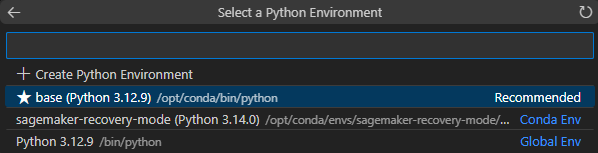

In [ ]:
# Retrieve the custom model deployment ARN from the previous notebook
# This ARN was stored when we successfully deployed the model to Bedrock
%store -r custom_model_deployment_arn

print(f"🚀 Using custom model deployment: {custom_model_deployment_arn}")
custom_model_deployment_arn

### 2 — Import libraries and define inference utilities

Brief: Import required libraries for image processing, AWS service interaction, and visualization. Define utility functions for downloading images from S3, loading test data, and displaying results.

Why we're doing this: The inference process requires several components: downloading images from S3 (where test data is stored), converting images to base64 format (required by Bedrock API), and creating visualization functions to display results alongside input images.

What to check after running: Verify all imports succeed and utility functions are properly defined. These functions will handle the complete inference workflow from data loading to result visualization.

**🔍 Key Functions Defined:**
- `download_s3_image_to_base64()`: Converts S3 images to base64 for API calls
- `load_test_data()`: Parses test dataset in Bedrock conversation format
- `display_image_and_results()`: Creates side-by-side visualization of inputs and outputs

In [ ]:
# Core libraries for inference and data handling
import json
import os
import base64
import boto3

# Libraries for image processing and visualization
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import io

def download_s3_image_to_base64(s3_uri, s3_client):
    """Download image from S3 and convert to base64."""
    bucket = s3_uri.split('/')[2]
    key = '/'.join(s3_uri.split('/')[3:])
    response = s3_client.get_object(Bucket=bucket, Key=key)
    return base64.b64encode(response['Body'].read()).decode('utf-8')

def download_s3_image_for_display(s3_uri, s3_client):
    bucket = s3_uri.split('/')[2]
    key = '/'.join(s3_uri.split('/')[3:])
    response = s3_client.get_object(Bucket=bucket, Key=key)
    image = Image.open(io.BytesIO(response['Body'].read()))
    
    if image.mode != 'RGB':
        image = image.convert('RGB')
    
    return image  # Return PIL Image, not np.array(image)


def load_test_data(metadata_path):
    """Load test data from Bedrock conversation format."""
    test_data = []
    with open(metadata_path, 'r') as f:
        for line in f:
            data = json.loads(line)
            user_content = data['messages'][0]['content']
            prompt = next(item['text'] for item in user_content if 'text' in item)
            s3_uri = next(item['image']['source']['s3Location']['uri'] for item in user_content if 'image' in item)
            expected = data['messages'][1]['content'][0]['text']
            system = data['system'][0]['text']
            
            test_data.append({
                'prompt': prompt,
                's3_uri': s3_uri,
                'expected': expected,
                'system': system
            })
    return test_data

def display_image_and_results(image, prompt, response_text, expected_completion):
    """Display the image alongside the inference results with proper color handling."""
    
    # Ensure it's in RGB mode to avoid color issues
    if hasattr(image, 'mode') and image.mode != 'RGB':
        image = image.convert('RGB')
    
    plt.figure(figsize=(15, 10), facecolor='white')  # Set figure background to white
    
    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap=None)  # Use original colors, no colormap
    plt.axis('off')
    plt.title('Input Image', color='black')  # Explicit black title
    
    plt.subplot(1, 2, 2)
    plt.axis('off')
    text_content = f"Prompt:\n{prompt}\n\nModel Response:\n{response_text}\n\nExpected Answer:\n{expected_completion}"
    
    # Create a white background for text and use black text
    plt.text(0, 0.5, text_content, fontsize=10, wrap=True, 
             verticalalignment='center', color='black',
             bbox=dict(boxstyle="round,pad=0.3", facecolor='white', edgecolor='gray'))
    
    plt.tight_layout()
    plt.show()

def perform_inference(metadata_path, custom_model_arn, region_name="us-east-1", num_samples=2):
    """Perform inference using test data with S3 images and display results."""
    bedrock_runtime = boto3.client("bedrock-runtime", region_name=region_name)
    s3_client = boto3.client("s3", region_name=region_name)
    
    test_data = load_test_data(metadata_path)[:num_samples]
    
    for i, item in enumerate(test_data, 1):
        try:
            base64_string = download_s3_image_to_base64(item['s3_uri'], s3_client)
            display_image = download_s3_image_for_display(item['s3_uri'], s3_client)
            
            request_body = {
                "messages": [{
                    "role": "user",
                    "content": [
                        {"image": {"format": "jpeg", "source": {"bytes": base64_string}}},
                        {"text": item['prompt']}
                    ]
                }],
                "system": [{"text": item['system']}],
                "inferenceConfig": {"max_new_tokens": 500, "top_p": 0.9, "temperature": 0.0}
            }

            response = bedrock_runtime.invoke_model(
                modelId=custom_model_arn,
                body=json.dumps(request_body)
            )
            
            model_response = json.loads(response["body"].read())
            response_text = model_response["output"]["message"]["content"][0]["text"]
            
            display_image_and_results(display_image, item['prompt'], response_text, item['expected'])
            
            print(f"\nTest {i}:")
            print(f"Image: {os.path.basename(item['s3_uri'])}")
            print(f"Prompt: {item['prompt']}")
            print(f"Model Response: {response_text}")
            print(f"Expected Answer: {item['expected']}")
            print("-" * 80)
            
        except Exception as e:
            print(f"Error processing test {i}: {str(e)}")

### 3 — Execute inference testing on document VQA samples

Brief: Run the complete inference testing workflow using your fine-tuned model. This will process test images, generate responses, and display visual comparisons between model outputs and expected answers.

Why we're doing this: This is the core validation step where we assess how well your fine-tuned model performs on document understanding tasks. By comparing model responses to ground truth answers, we can evaluate the effectiveness of the fine-tuning process.

What to check after running: Look for accurate responses to document-based questions, proper understanding of visual elements, and improvements over what a base model might produce. Pay attention to both the accuracy and the reasoning quality in the responses.

**💡 Evaluation Criteria:**
- Accuracy: Does the model extract the correct information from the document?
- Completeness: Are the responses comprehensive and well-structured?
- Relevance: Does the model focus on the relevant parts of the document?
- Consistency: Are similar questions answered in a consistent manner?

**🔍 Exploration Task**: After running the inference, analyze the model's responses. What patterns do you notice? Where does the fine-tuned model excel compared to a general-purpose model?

In [ ]:
# Execute inference testing on the fine-tuned model
# This will process test samples and display visual results

if __name__ == "__main__":
    # Configuration for inference testing
    METADATA_PATH = "./Nova_DocVQA_local/test/test.jsonl"
    CUSTOM_MODEL_ARN = custom_model_deployment_arn  # Use the deployment ARN from previous step
    REGION_NAME = "us-east-1"
    
    print("🧪 Starting inference testing on fine-tuned Nova-Lite model...")
    print(f"📊 Test data location: {METADATA_PATH}")
    print(f"🎯 Model ARN: {CUSTOM_MODEL_ARN}")
    print(f"🌍 Region: {REGION_NAME}")
    print("" + "-" * 80)
    
    # Perform inference on test samples
    perform_inference(
        metadata_path=METADATA_PATH,
        custom_model_arn=CUSTOM_MODEL_ARN,
        region_name=REGION_NAME,
        num_samples=4  # Test with 4 samples - increase this number to test more examples
    )
    
    print("\n✅ Inference testing completed!")
    print("\n📈 Next Steps:")
    print("   • Analyze the model responses above")
    print("   • Compare accuracy against expected answers")
    print("   • Consider additional fine-tuning if needed")

### 4 — Retrieve CloudFront domain URL of Test application

Brief: Retrieve the CloudFront domain URL that hosts a web application interface for testing your model. This provides an alternative way to interact with your fine-tuned model through a user-friendly web interface.

Why we're doing this: While programmatic testing is essential for validation, a web interface allows for more interactive testing and can be useful for demonstrating your model's capabilities to stakeholders or for manual testing with custom images.

What to check after running: Note the CloudFront domain URL that's displayed. You can use this URL to access a web application that interfaces with your deployed model.

**Web Application Features:**
- Upload custom document images
- Ask questions about uploaded documents
- Compare responses from different models
- Interactive testing environment

In [ ]:
import subprocess

# Run the AWS CLI command and capture the output
command = "aws ssm get-parameter --name '/nova-workshop/cloudfront-domain' --query 'Parameter.Value' --output text"
domain = subprocess.check_output(command, shell=True).decode('utf-8').strip()

# Using HTML (Option 1)
from IPython.display import HTML
HTML(f'Click here: &lt;a href="https://{domain}" target="_blank"&gt;{domain}&lt;/a&gt;')

# OR using Markdown (Option 2)
from IPython.display import Markdown
Markdown(f'Click here: [{domain}](https://{domain})')


### 5 — Click on the link above to launch the Test Application.

1. The first time you login, you will have to Create an account:

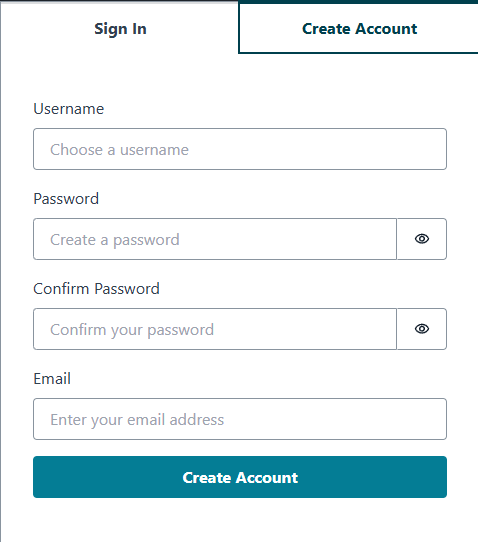

2. Once you create an account and login, you can see the images from the Test set along with their Question-Answer pairs.

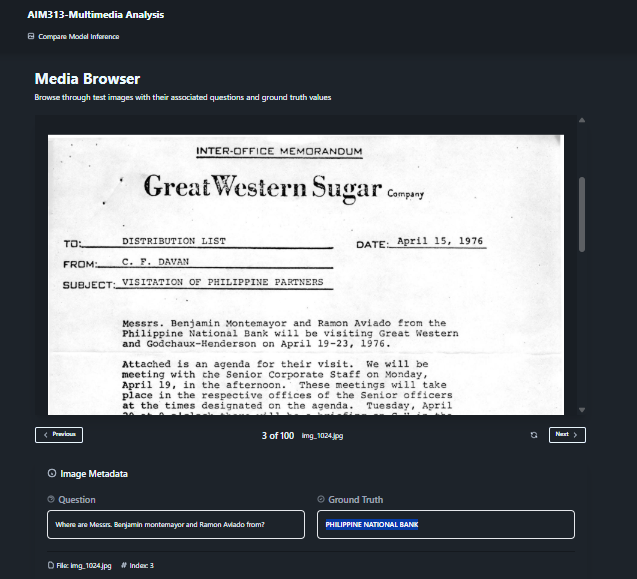

**⚠️ Note**: You may click on the zoom button on the top-right corner to view the full image.

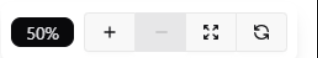

3. Further, you can click the "Connect" button followed by "Submit Analysis" to compare the Inference results of fine-tuned Nova-lite with pre-trained Nova-lite and Claude 4.5 Haiku. 

**⚠️ Note**: There may be Bedrock RPM (Requests per minute) limits, so limit your testing to under 5 images. 

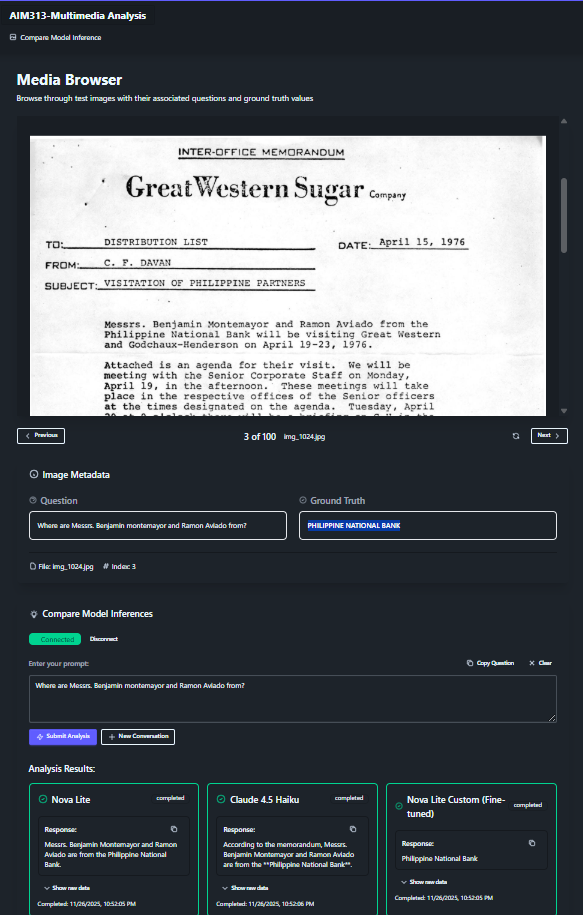



## 🎉 Lab 4 Completion Summary


Congratulations! You have successfully completed the inference testing lab. Here's what you accomplished:

**✅ Key Achievements:**
- Successfully tested your fine-tuned Nova-Lite model on DocumentVQA tasks
- Evaluated model performance through visual and qualitative assessment
- Learned to use the Bedrock Runtime API for custom model inference
- Gained insights into your model's strengths and areas for improvement

**🔍 What You Learned:**
- How to structure inference requests for multimodal models
- Best practices for model validation and testing
- Techniques for comparing model outputs against ground truth
- Methods for visualizing and analyzing model performance

**🚀 Next Step:**
- Quantitative evaluation of the custom Nova-Lite model against pretrained Nova-Lite or other Bedrock models.

### **Ready for Quantitative Evaluations? Proceed to Lab 5!**